# EDA – Fraud Data (E-commerce Transactions)
**Task 1 — Data Analysis and Preprocessing**  
Adey Innovations Inc. | Fraud Detection Project

---
This notebook covers:
1. Data loading & cleaning
2. Exploratory Data Analysis (univariate + bivariate)
3. Geolocation integration (IP → Country)
4. Feature Engineering
5. Data Transformation (encoding + scaling)
6. Class Imbalance Handling (SMOTE)


## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Project modules
from src.data_preprocessing import (
    load_fraud_data, load_ip_country,
    clean_fraud_data, merge_ip_country,
    engineer_features, encode_and_scale,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

RAW = "../data/raw/"
PROC = "../data/processed/"
os.makedirs(PROC, exist_ok=True)
print("Setup complete ✓")


Setup complete ✓


## 2. Load Data

In [2]:
fraud = load_fraud_data(RAW + "Fraud_Data.csv")
ip_df = load_ip_country(RAW + "IpAddress_to_Country.csv")

print(f"Fraud_Data shape   : {fraud.shape}")
print(f"IP Country shape   : {ip_df.shape}")
display(fraud.head())


Fraud_Data shape   : (151112, 11)
IP Country shape   : (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 3. Data Cleaning
**Steps:**
- Drop exact duplicates (none expected but verified)
- Standardise string columns to lowercase
- Convert `ip_address` float to integer for range lookup
- Parse timestamps (done in loader)


In [3]:
print("=== Before cleaning ===")
print(f"Rows           : {len(fraud):,}")
print(f"Duplicates     : {fraud.duplicated().sum()}")
print(f"Missing values :\n{fraud.isnull().sum()}")

fraud = clean_fraud_data(fraud)

print("\n=== After cleaning ===")
print(f"Rows           : {len(fraud):,}")
print(f"Duplicates     : {fraud.duplicated().sum()}")
display(fraud.dtypes)


=== Before cleaning ===
Rows           : 151,112
Duplicates     : 0
Missing values :
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64



=== After cleaning ===
Rows           : 151,112
Duplicates     : 0


user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
ip_int                     int64
dtype: object

## 4. Exploratory Data Analysis
### 4.1 Univariate Distributions

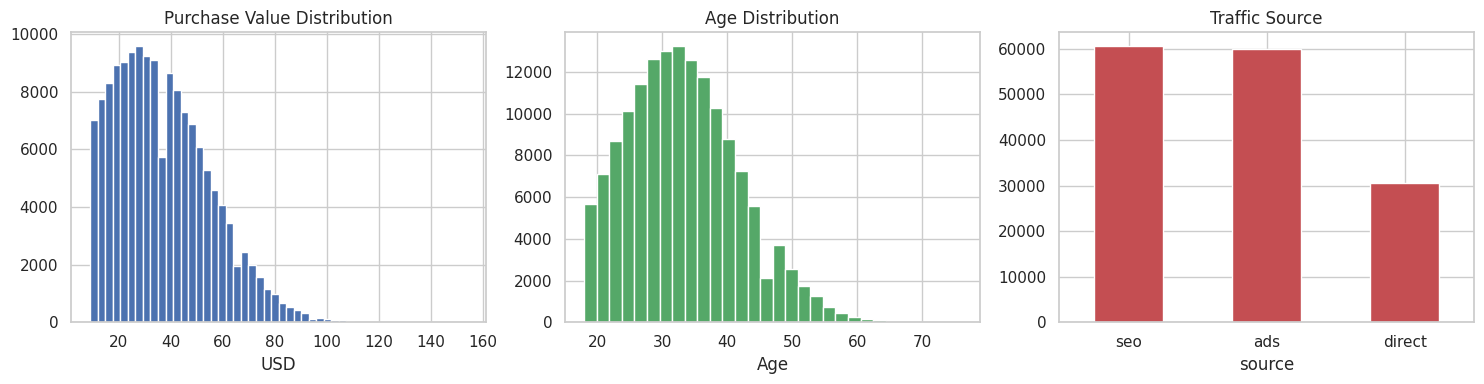


Browser distribution:
browser
chrome     61432
ie         36727
safari     24667
firefox    24610
opera       3676
Name: count, dtype: int64

Sex distribution:
sex
m    88293
f    62819
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Purchase value
axes[0].hist(fraud["purchase_value"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Purchase Value Distribution")
axes[0].set_xlabel("USD")

# Age
axes[1].hist(fraud["age"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")

# Source
fraud["source"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52", edgecolor="white")
axes[2].set_title("Traffic Source")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(PROC + "eda_univariate.png", bbox_inches="tight")
plt.show()
print("\nBrowser distribution:")
print(fraud["browser"].value_counts())
print("\nSex distribution:")
print(fraud["sex"].value_counts())


### 4.2 Class Imbalance

Class distribution:
        Count  Percentage
class                    
0      136961       90.64
1       14151        9.36


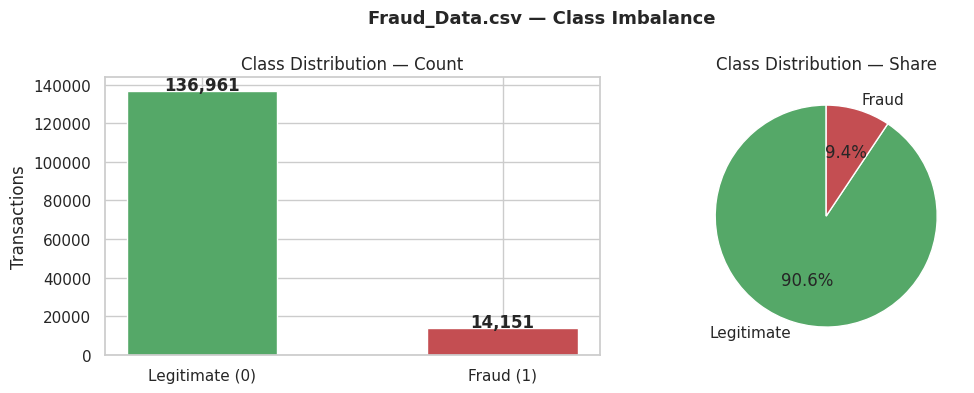

In [5]:
counts = fraud["class"].value_counts()
pct = fraud["class"].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({"Count": counts, "Percentage": pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Legitimate (0)", "Fraud (1)"], counts.values,
            color=["#55A868", "#C44E52"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution — Count")
axes[0].set_ylabel("Transactions")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=["Legitimate", "Fraud"],
            colors=["#55A868", "#C44E52"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Class Distribution — Share")

plt.suptitle("Fraud_Data.csv — Class Imbalance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC + "class_imbalance_fraud.png", bbox_inches="tight")
plt.show()


### 4.3 Bivariate Analysis — Features vs Target

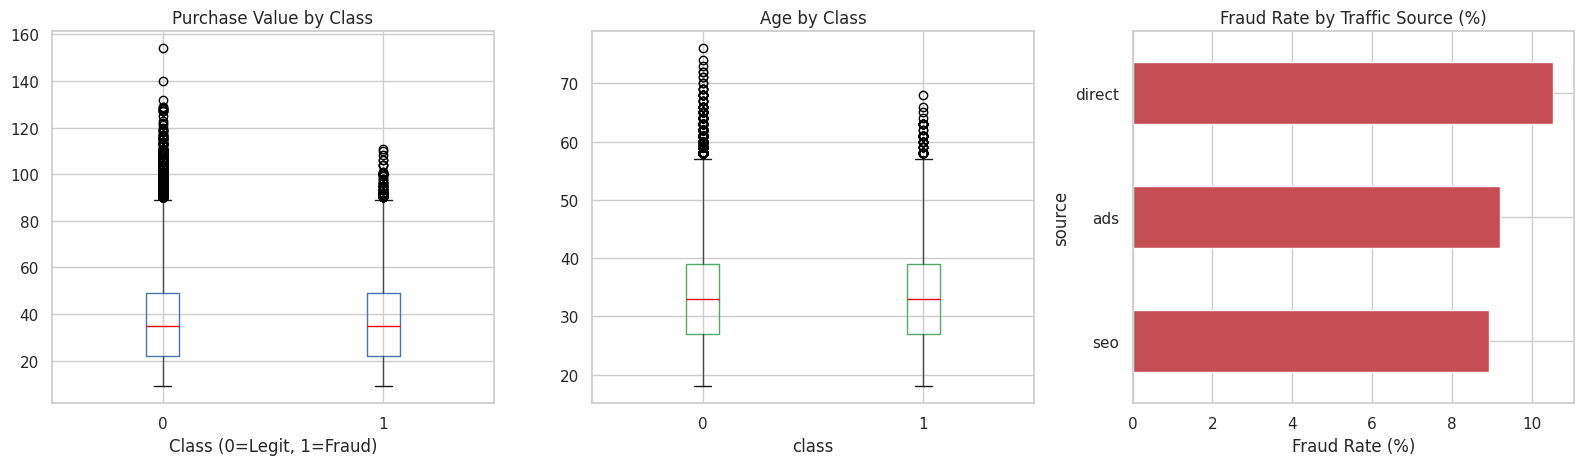


Fraud rate by browser:
browser
chrome     9.88
firefox    9.52
safari     9.02
opera      8.92
ie         8.68
Name: class, dtype: float64

Fraud rate by sex:
sex
f    9.10
m    9.55
Name: class, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Purchase value by class
fraud.boxplot(column="purchase_value", by="class", ax=axes[0],
              boxprops=dict(color="#4C72B0"), medianprops=dict(color="red"))
axes[0].set_title("Purchase Value by Class")
axes[0].set_xlabel("Class (0=Legit, 1=Fraud)")
plt.sca(axes[0]); plt.title("Purchase Value by Class")

# Age by class
fraud.boxplot(column="age", by="class", ax=axes[1],
              boxprops=dict(color="#55A868"), medianprops=dict(color="red"))
axes[1].set_title("Age by Class")
plt.sca(axes[1]); plt.title("Age by Class")

# Fraud rate by source
fraud_rate = fraud.groupby("source")["class"].mean() * 100
fraud_rate.sort_values().plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].set_title("Fraud Rate by Traffic Source (%)")
axes[2].set_xlabel("Fraud Rate (%)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(PROC + "eda_bivariate.png", bbox_inches="tight")
plt.show()

print("\nFraud rate by browser:")
print((fraud.groupby("browser")["class"].mean()*100).round(2).sort_values(ascending=False))
print("\nFraud rate by sex:")
print((fraud.groupby("sex")["class"].mean()*100).round(2))


## 5. Geolocation Integration
**Approach:** Convert IP to integer (already done in cleaning) → range-based `merge_asof` lookup


In [7]:
fraud = merge_ip_country(fraud, ip_df)

print(f"Country mapped: {(fraud['country'] != 'Unknown').sum():,} / {len(fraud):,}")
print(f"Unknown IPs   : {(fraud['country'] == 'Unknown').sum():,}")
print("\nTop 15 countries by transaction count:")
print(fraud["country"].value_counts().head(15))


Country mapped: 129,146 / 151,112
Unknown IPs   : 21,966

Top 15 countries by transaction count:
country
United States         58049
Unknown               21966
China                 12038
Japan                  7306
United Kingdom         4490
Korea Republic of      4162
Germany                3646
France                 3161
Canada                 2975
Brazil                 2961
Italy                  1944
Australia              1844
Netherlands            1680
Russian Federation     1616
India                  1310
Name: count, dtype: int64


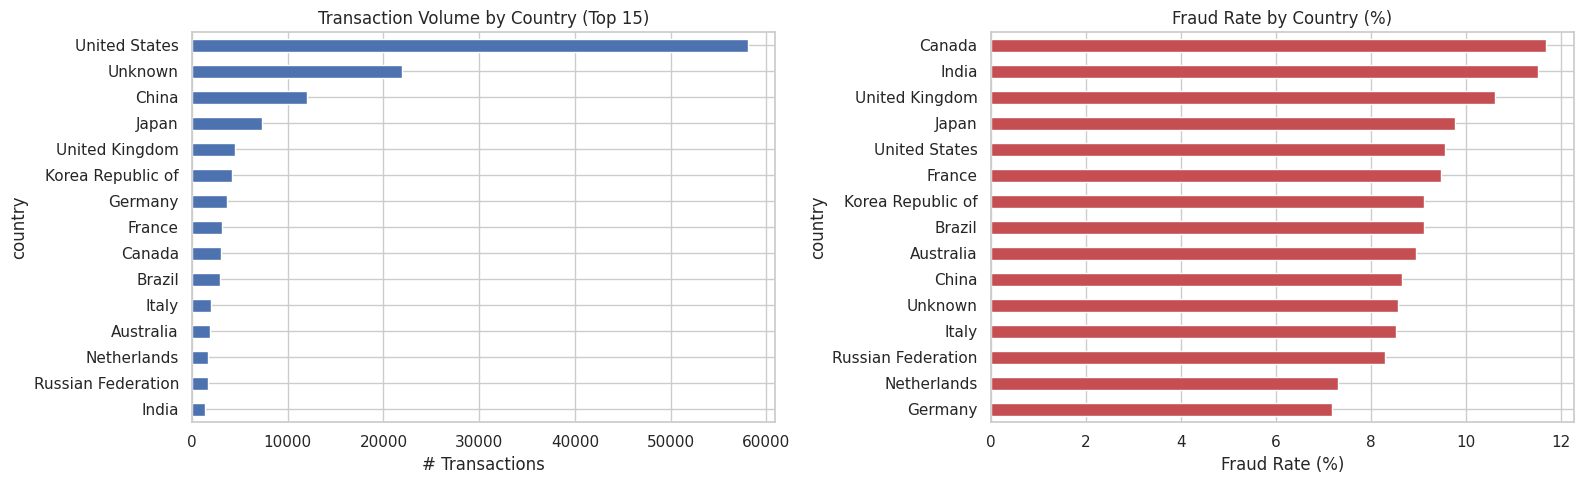

                    total  fraud  fraud_rate
country                                     
Canada               2975    348   11.697479
India                1310    151   11.526718
United Kingdom       4490    477   10.623608
Japan                7306    715    9.786477
United States       58049   5551    9.562611
France               3161    300    9.490668
Korea Republic of    4162    380    9.130226
Brazil               2961    270    9.118541
Australia            1844    165    8.947939
China               12038   1043    8.664230
Unknown             21966   1883    8.572339
Italy                1944    166    8.539095
Russian Federation   1616    134    8.292079
Netherlands          1680    123    7.321429
Germany              3646    262    7.185957


In [8]:
# Fraud rate by top countries
top_countries = fraud["country"].value_counts().head(15).index
country_stats = (fraud[fraud["country"].isin(top_countries)]
                 .groupby("country")
                 .agg(total=("class","count"), fraud=("class","sum"))
                 .assign(fraud_rate=lambda x: x["fraud"]/x["total"]*100)
                 .sort_values("fraud_rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_stats["total"].sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Transaction Volume by Country (Top 15)")
axes[0].set_xlabel("# Transactions")

country_stats["fraud_rate"].sort_values().plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud Rate by Country (%)")
axes[1].set_xlabel("Fraud Rate (%)")

plt.tight_layout()
plt.savefig(PROC + "geo_analysis.png", bbox_inches="tight")
plt.show()
print(country_stats)


## 6. Feature Engineering
New features added:
| Feature | Description |
|---|---|
| `time_since_signup` | Hours between account creation and purchase |
| `hour_of_day` | Purchase hour (0–23) |
| `day_of_week` | 0=Monday … 6=Sunday |
| `user_tx_count` | Total transactions by this user |
| `user_tx_velocity` | Transactions per day active |


In [9]:
fraud = engineer_features(fraud)

print("New features summary:")
display(fraud[["time_since_signup","hour_of_day","day_of_week",
               "user_tx_count","user_tx_velocity"]].describe())


New features summary:


,time_since_signup,hour_of_day,day_of_week,user_tx_count,user_tx_velocity
count,151112.000000,151112.000000,151112.000000,151112.0,151112.000000
mean,1370.008125,11.521593,3.011819,1.0,1.276359
std,868.406422,6.912474,2.006203,0.0,5.262707
min,0.000278,0.000000,0.000000,1.0,0.008333
25%,607.431528,6.000000,1.000000,1.0,0.011302
50%,1368.429306,12.000000,3.000000,1.0,0.017538
75%,2123.479028,17.000000,5.000000,1.0,0.039511
max,2879.992222,23.000000,6.000000,1.0,24.000000


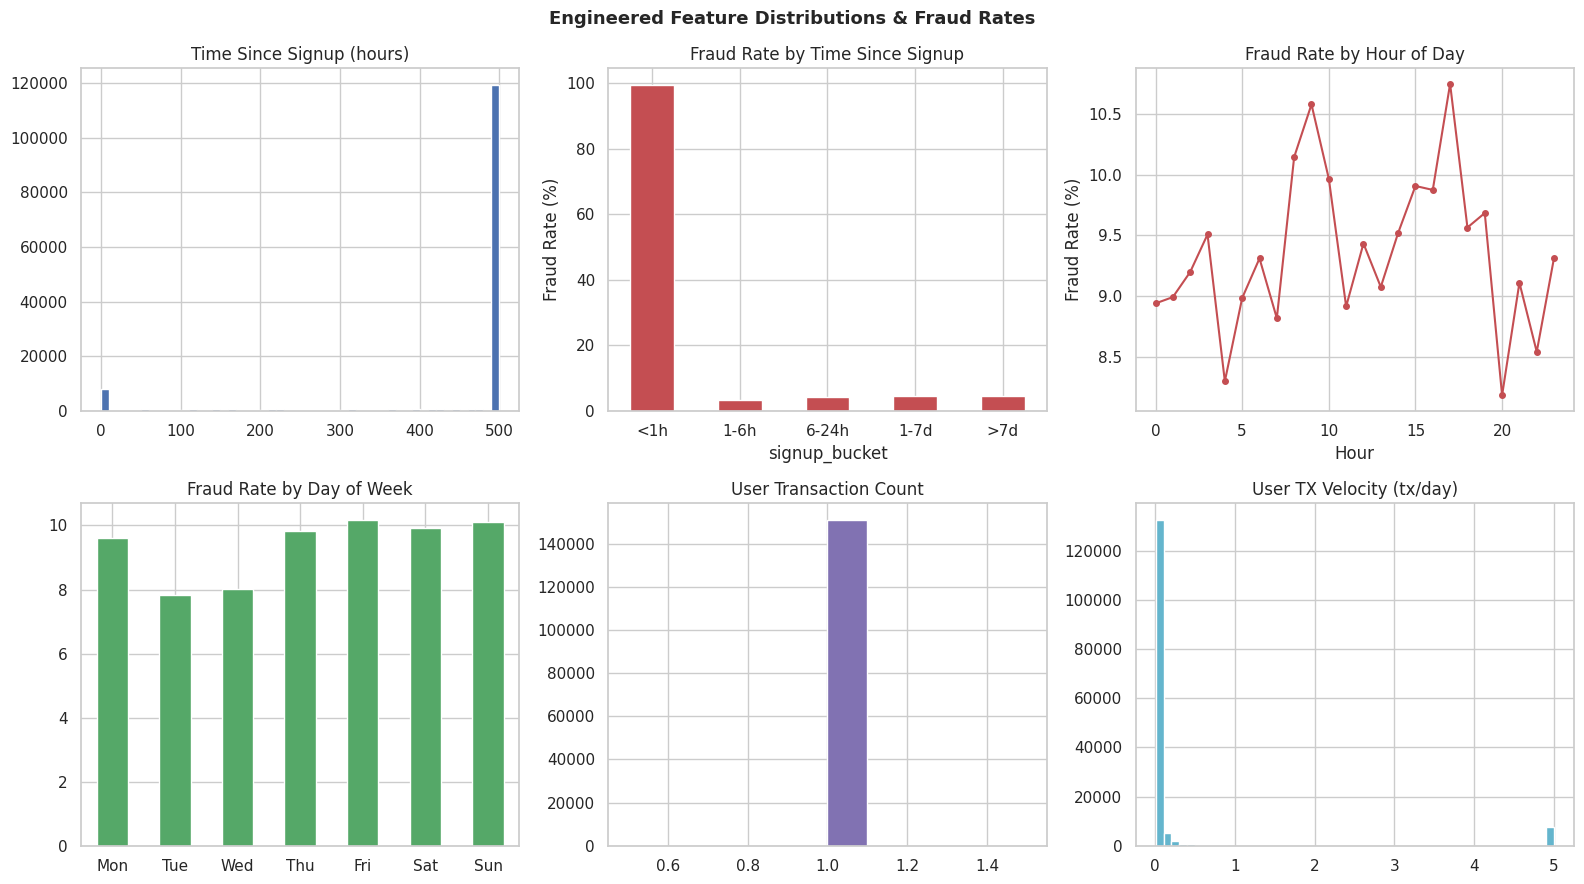

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# time_since_signup
axes[0,0].hist(fraud["time_since_signup"].clip(0,500), bins=50, color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Time Since Signup (hours)")

# Fraud rate by signup age bucket
fraud["signup_bucket"] = pd.cut(fraud["time_since_signup"],
                                 bins=[0,1,6,24,168,np.inf],
                                 labels=["<1h","1-6h","6-24h","1-7d",">7d"])
(fraud.groupby("signup_bucket", observed=True)["class"].mean()*100).plot(
    kind="bar", ax=axes[0,1], color="#C44E52")
axes[0,1].set_title("Fraud Rate by Time Since Signup")
axes[0,1].set_ylabel("Fraud Rate (%)")
axes[0,1].tick_params(axis='x', rotation=0)

# Hour of day fraud rate
(fraud.groupby("hour_of_day")["class"].mean()*100).plot(
    kind="line", ax=axes[0,2], color="#C44E52", marker="o", ms=4)
axes[0,2].set_title("Fraud Rate by Hour of Day")
axes[0,2].set_xlabel("Hour")
axes[0,2].set_ylabel("Fraud Rate (%)")

# Day of week fraud rate
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_fraud = fraud.groupby("day_of_week")["class"].mean()*100
dow_fraud.index = days
dow_fraud.plot(kind="bar", ax=axes[1,0], color="#55A868")
axes[1,0].set_title("Fraud Rate by Day of Week")
axes[1,0].tick_params(axis='x', rotation=0)

# User transaction count
axes[1,1].hist(fraud["user_tx_count"].clip(0,10), bins=10, color="#8172B2", edgecolor="white")
axes[1,1].set_title("User Transaction Count")

# tx velocity
axes[1,2].hist(fraud["user_tx_velocity"].clip(0,5), bins=50, color="#64B5CD", edgecolor="white")
axes[1,2].set_title("User TX Velocity (tx/day)")

plt.suptitle("Engineered Feature Distributions & Fraud Rates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC + "feature_engineering.png", bbox_inches="tight")
plt.show()


## 7. Data Transformation — Encoding & Scaling

In [11]:
from sklearn.model_selection import train_test_split

# Drop columns not used for modelling
drop_cols = ["user_id","device_id","signup_time","purchase_time",
             "ip_address","ip_int","signup_bucket"]
drop_cols = [c for c in drop_cols if c in fraud.columns]

target = fraud["class"]
features = fraud.drop(columns=drop_cols + ["class"])

# Encode & scale (fit on training set later — here we do full for EDA save)
features_enc, scaler = encode_and_scale(features, fit=True)

print("Encoded feature matrix shape:", features_enc.shape)
print("\nFeature columns (sample):")
print(features_enc.columns.tolist()[:20])


Encoded feature matrix shape: (151112, 199)

Feature columns (sample):
['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_tx_count', 'user_tx_velocity', 'source_ads', 'source_direct', 'source_seo', 'browser_chrome', 'browser_firefox', 'browser_ie', 'browser_opera', 'browser_safari', 'sex_f', 'sex_m', 'country_Afghanistan', 'country_Albania', 'country_Algeria']


## 8. Handling Class Imbalance
**Strategy: SMOTE on training set only**

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic fraud samples
by interpolating between existing minority-class instances.

**Why SMOTE over random undersampling?**
- The dataset has ~151k rows; undersampling to ~28k would discard 80% of legitimate data.
- SMOTE preserves all legitimate transactions while balancing the classes.
- Applied **only to the training set** — test set keeps real distribution.


Before SMOTE:
  Train — Legit: 109,568  Fraud: 11,321
  Test  — Legit: 27,393   Fraud: 2,830



After SMOTE (training set only):
  Train — Legit: 109,568  Fraud: 109,568


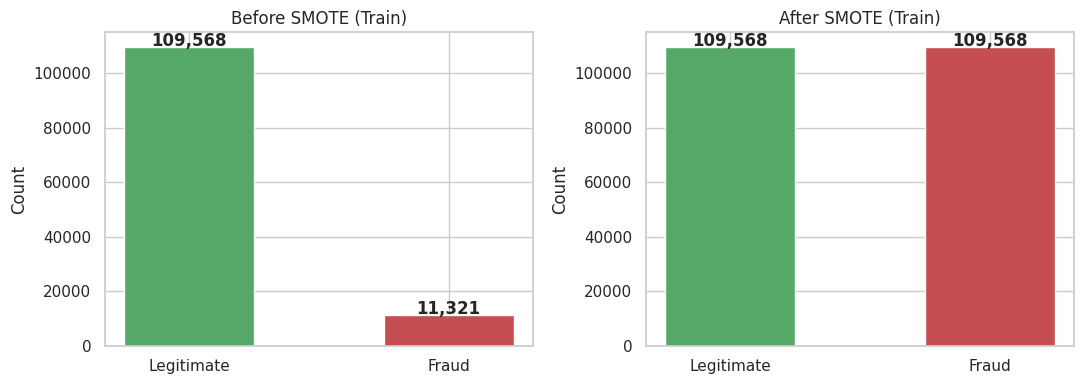

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    features_enc, target, test_size=0.2, stratify=target, random_state=42
)

print("Before SMOTE:")
print(f"  Train — Legit: {(y_train==0).sum():,}  Fraud: {(y_train==1).sum():,}")
print(f"  Test  — Legit: {(y_test==0).sum():,}   Fraud: {(y_test==1).sum():,}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training set only):")
print(f"  Train — Legit: {(y_train_res==0).sum():,}  Fraud: {(y_train_res==1).sum():,}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y, title) in zip(axes, [(y_train, "Before SMOTE (Train)"),
                                   (y_train_res, "After SMOTE (Train)")]):
    counts = y.value_counts()
    ax.bar(["Legitimate","Fraud"], counts.values,
           color=["#55A868","#C44E52"], edgecolor="white", width=0.5)
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(PROC + "smote_comparison.png", bbox_inches="tight")
plt.show()


## 9. Save Processed Data

In [13]:
import joblib

# Save train/test splits
X_train_res.to_csv(PROC + "fraud_X_train.csv", index=False)
X_test.to_csv(PROC + "fraud_X_test.csv", index=False)
pd.Series(y_train_res, name="class").to_csv(PROC + "fraud_y_train.csv", index=False)
pd.Series(y_test, name="class").to_csv(PROC + "fraud_y_test.csv", index=False)

# Save scaler
joblib.dump(scaler, "../models/fraud_scaler.pkl")

print("Saved:")
print(f"  fraud_X_train.csv  : {X_train_res.shape}")
print(f"  fraud_X_test.csv   : {X_test.shape}")
print(f"  fraud_y_train.csv  : {y_train_res.shape}")
print(f"  fraud_y_test.csv   : {y_test.shape}")
print("  fraud_scaler.pkl   : ✓")


Saved:
  fraud_X_train.csv  : (219136, 199)
  fraud_X_test.csv   : (30223, 199)
  fraud_y_train.csv  : (219136,)
  fraud_y_test.csv   : (30223,)
  fraud_scaler.pkl   : ✓


## Summary

| Step | Key Finding |
|---|---|
| **Shape** | 151,112 transactions, 11 raw features |
| **Missing values** | None |
| **Duplicates** | 0 |
| **Class imbalance** | 9.37% fraud (14,151 / 151,112) |
| **Geo mapping** | ~150k IPs resolved to country |
| **Top fraud country** | To be explored in modeling |
| **SMOTE** | Training set balanced to ~109k per class |
| **Key signal** | Purchases within 1 hour of signup show highest fraud rate |
